### Ridge Regression Model for Predicting log(C‑Peptide AUC)

We model the log‑transformed 4‑hour C‑peptide AUC as a linear function of autoantibodies and demographics.

<div style="text-align: left">

$$
\log(\text{C‑peptide AUC}) =
\beta_0
+ \beta_{\text{GAD65}} \cdot \text{GAD65}
+ \beta_{\text{IA2IC}} \cdot \text{IA2IC}
+ \beta_{\text{MIAA}} \cdot \text{MIAA}
+ \beta_{\text{ICA}} \cdot \text{ICA}
+ \beta_{\text{ZNT8}} \cdot \text{ZNT8}
+ \beta_{8\text{–}12} \cdot I_{8\text{–}12}
+ \beta_{13\text{–}17} \cdot I_{13\text{–}17}
+ \beta_{>18} \cdot I_{>18}
+ \beta_{\text{Sex}} \cdot \text{Sex}
$$
</div>

Where:

**Where:**

- $ \beta_0 $ is the intercept  
- $ \beta_i $ are the learned Ridge regression coefficients  
- $ I_{\text{Age Group}} $ is a one-hot encoded indicator for age group  
- Sex is encoded as 0 = Male, 1 = Female


This model is trained using Ridge regression to stabilize coefficients across small, multi‑study datasets and enable federated coefficient averaging.

This Ridge regression model is trained separately for each study using local data and evaluated using mean squared error (MSE), median squared error, and interquartile range (IQR).  
We then compare this local performance to a **federated Ridge model** constructed by aggregating coefficients across studies.


In [1]:
# ========== STEP 0: Set working directory (for running locally on laptop) =========
from __future__ import annotations
import sys, os, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)
print("Repo:", REPO)

Repo: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


In [2]:
# === Load Panel A data via the shared loader (src/oadr_data.py) ===
#
# The shared loader normalises per-study quirks that previously caused this
# notebook to fail with `KeyError: ['C_Peptide_AUC_4Hrs'] not in index`:
#
#   - SDY524's subject-identifier column is `ImmPort Accession`, not `Subject_ID`.
#   - SDY569's c-peptide file has the typo `Subject_IDel`.
#   - SDY1737's c-peptide column is `C_Peptide_AUC` (no `_4Hrs` suffix).
#   - SDY1737's age-group bin `>30` is recoded to the schema used by the others.
#
# The loader returns a wide-format dataframe with one row per subject and the
# standardised columns: 5 autoantibodies, Age_Group, 3 one-hot age indicators
# (`8-12`, `13-17`, `>18`), Sex, Study, C_Peptide_AUC_4Hrs, and log_auc.

import oadr_data as od
import pandas as pd

# Studies historically modeled in this notebook.  Panel A also includes SDY524;
# add it here if you want a four-study run.
STUDIES = ["SDY569", "SDY797", "SDY1737"]

panel_dfs = {study: od.load_panel_a(study) for study in STUDIES}

for study, df in panel_dfs.items():
    print(f"{study}: {len(df)} subjects")


SDY569: 10 subjects
SDY797: 49 subjects
SDY1737: 16 subjects


In [3]:
# Quick sanity check on the loaded panel data per study.
# The loader returns three one-hot age-group indicator columns ("8-12", "13-17",
# ">18") rather than a single "Age_Group" column, so we summarise those directly.

for study, df in panel_dfs.items():
    print(f"\n=== {study} ===")
    print(f"  shape: {df.shape}")
    print(f"  C_Peptide_AUC_4Hrs range: {df['C_Peptide_AUC_4Hrs'].min():.3f} - {df['C_Peptide_AUC_4Hrs'].max():.3f}")
    print(f"  log_auc range: {df['log_auc'].min():.3f} - {df['log_auc'].max():.3f}")
    age_counts = {ind: int(df[ind].sum()) for ind in ("8-12", "13-17", ">18") if ind in df.columns}
    print(f"  Age-group counts: {age_counts}")
    print(f"  Sex distribution: {df['Sex'].value_counts().to_dict()}")



=== SDY569 ===
  shape: (10, 13)
  C_Peptide_AUC_4Hrs range: 0.152 - 1.556
  log_auc range: -1.883 - 0.442
  Age-group counts: {'8-12': 6, '13-17': 1, '>18': 3}
  Sex distribution: {0.0: 7, 1.0: 3}

=== SDY797 ===
  shape: (49, 13)
  C_Peptide_AUC_4Hrs range: 0.223 - 1.663
  log_auc range: -1.502 - 0.509
  Age-group counts: {'8-12': 49, '13-17': 0, '>18': 0}
  Sex distribution: {0.0: 29, 1.0: 20}

=== SDY1737 ===
  shape: (16, 13)
  C_Peptide_AUC_4Hrs range: 0.119 - 1.521
  log_auc range: -2.130 - 0.419
  Age-group counts: {'8-12': 5, '13-17': 6, '>18': 5}
  Sex distribution: {0.0: 10, 1.0: 6}



Distributions for SDY569:


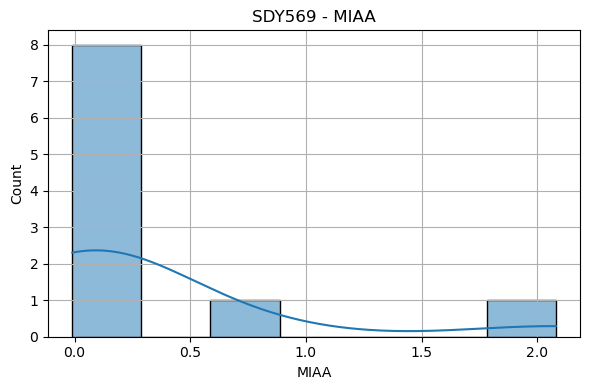

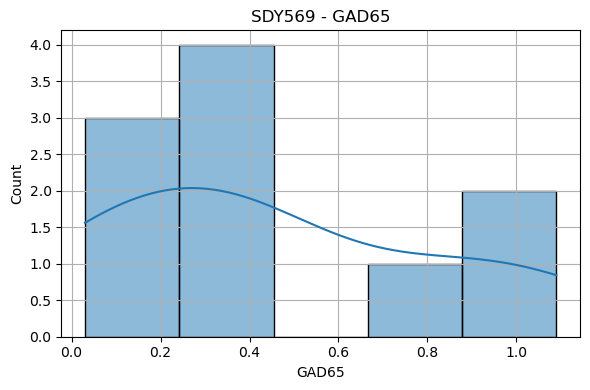

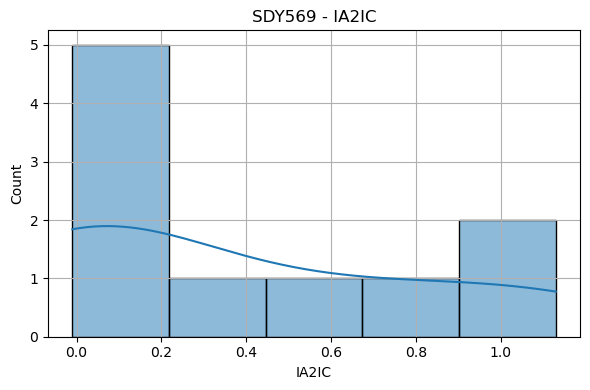

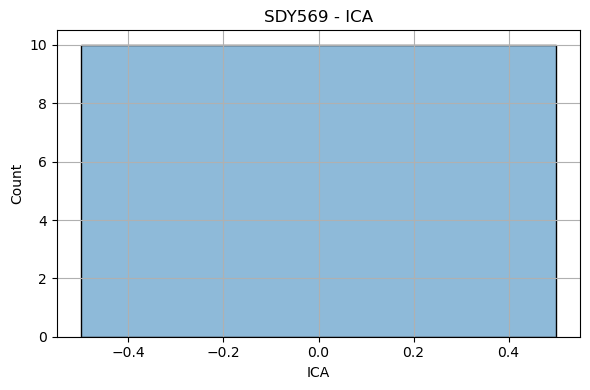

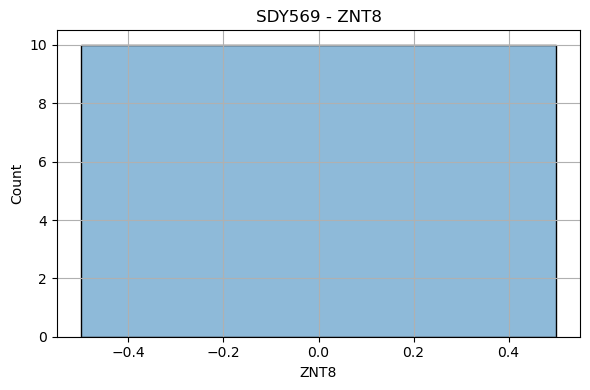


Distributions for SDY797:


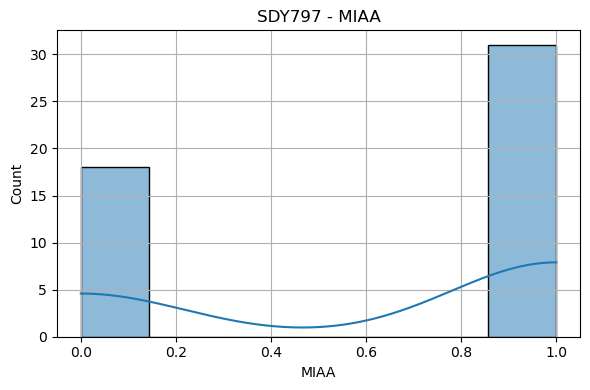

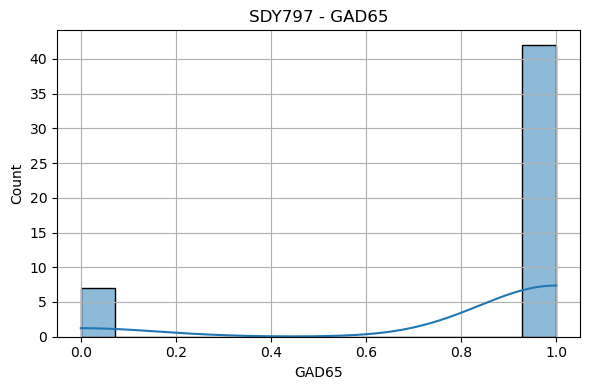

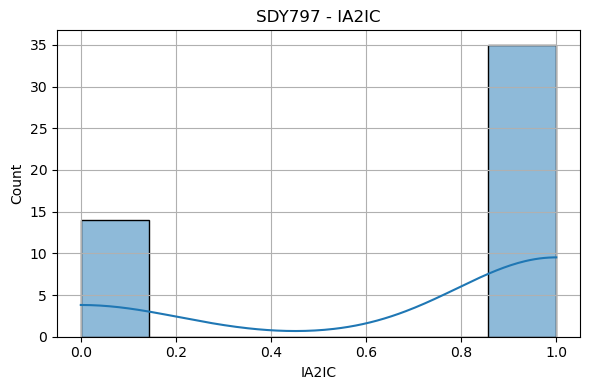

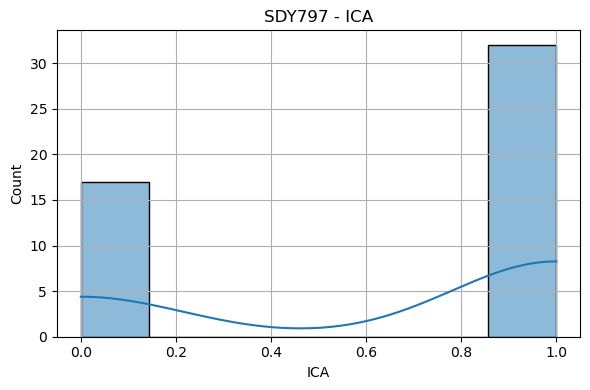

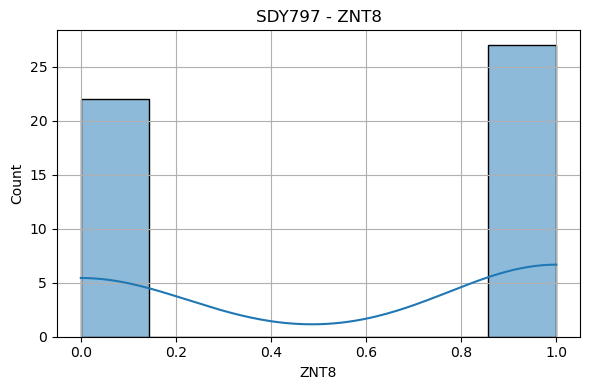


Distributions for SDY1737:


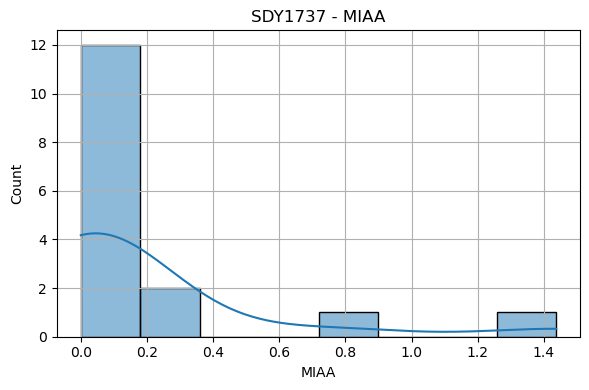

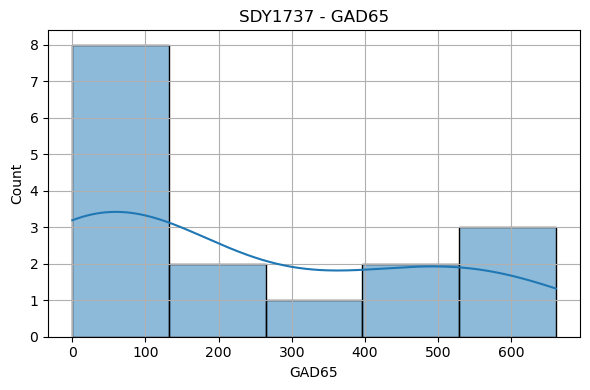

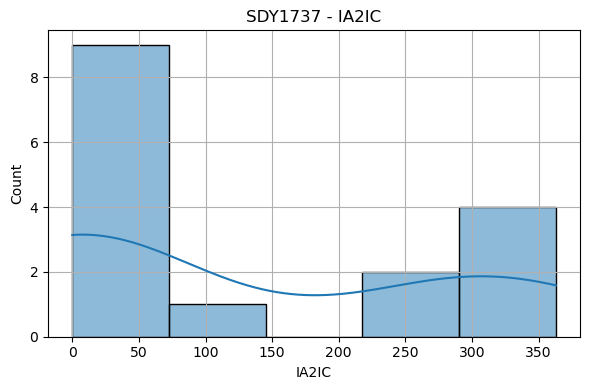

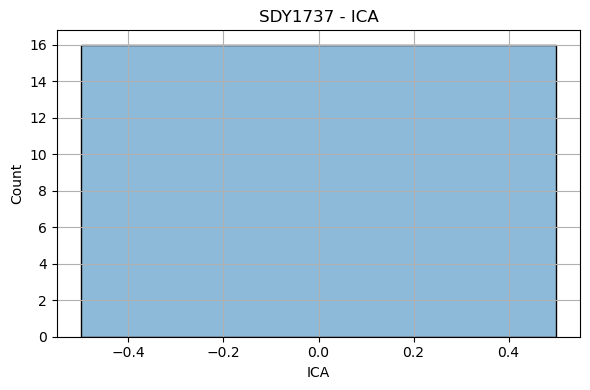

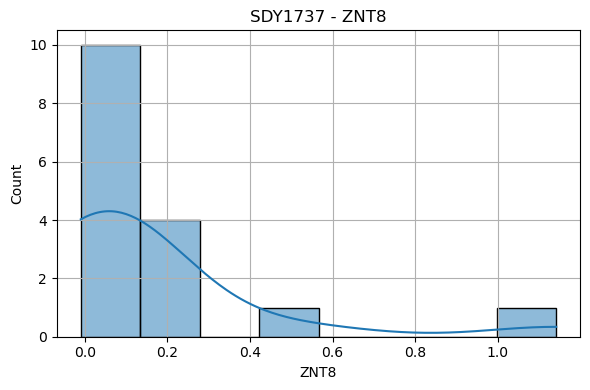

In [4]:
# Feature distribution plots — Panel A autoantibodies per study.
# The oadr_data loader returns wide format, so no pivot is needed.

import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ["MIAA", "GAD65", "IA2IC", "ICA", "ZNT8"]

for study, df in panel_dfs.items():
    print(f"\nDistributions for {study}:")
    for feature in features_to_plot:
        if feature in df.columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(df[feature].dropna(), kde=True)
            plt.title(f"{study} - {feature}")
            plt.xlabel(feature)
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  [SKIP] {feature} not found in {study}")


In [5]:
# Build per-study Ridge inputs via the shared design-matrix helper.
#
# `od.panel_a_design_matrix(df)` returns:
#   X: pandas.DataFrame, the 9-feature design matrix
#      (5 autoantibodies + 3 one-hot age-group indicators + Sex)
#   y: pandas.Series, log(C-peptide AUC)
#   feature_names: list of the 9 column names

import numpy as np

ridge_ready_dfs = {}
for study, df in panel_dfs.items():
    X, y, feature_names = od.panel_a_design_matrix(df)
    ridge_ready_dfs[study] = {"X": X, "y": y.values}
    print(f"{study}: X shape {X.shape}, y shape {y.shape}")
    print(f"  features: {feature_names}")


SDY569: X shape (10, 9), y shape (10,)
  features: ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']
SDY797: X shape (49, 9), y shape (49,)
  features: ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']
SDY1737: X shape (16, 9), y shape (16,)
  features: ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']



===== Ridge regression for SDY569 =====
Mean MSE:   0.5847
Median MSE: 0.7278
IQR:        0.5524

Regression coefficients:
13-17    1.577163
MIAA     0.483656
IA2IC    0.348196
ICA      0.000000
ZNT8     0.000000
>18      0.000000
Sex      0.000000
8-12    -1.577163
GAD65   -1.824218
dtype: float64
Intercept: 0.8568


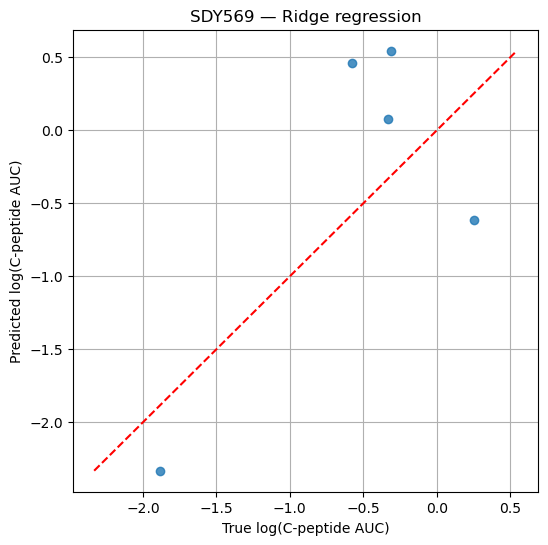


===== Ridge regression for SDY797 =====
Mean MSE:   0.3534
Median MSE: 0.2596
IQR:        0.5228

Regression coefficients:
IA2IC    0.279646
MIAA     0.061329
8-12     0.000000
13-17    0.000000
>18      0.000000
ICA     -0.028554
Sex     -0.062245
GAD65   -0.112305
ZNT8    -0.229757
dtype: float64
Intercept: -0.1953


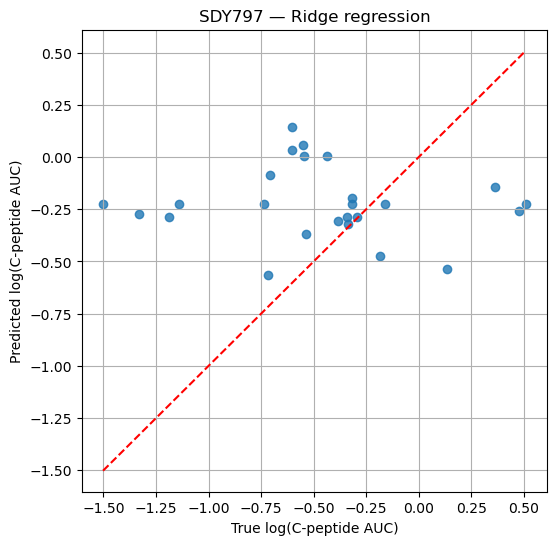


===== Ridge regression for SDY1737 =====
Mean MSE:   7.6970
Median MSE: 6.0071
IQR:        12.1484

Regression coefficients:
ZNT8     5.391454
Sex      3.605986
MIAA     2.454149
13-17    1.799464
ICA      0.000000
GAD65   -0.002079
IA2IC   -0.003034
8-12    -0.314387
>18     -1.485077
dtype: float64
Intercept: -2.1661


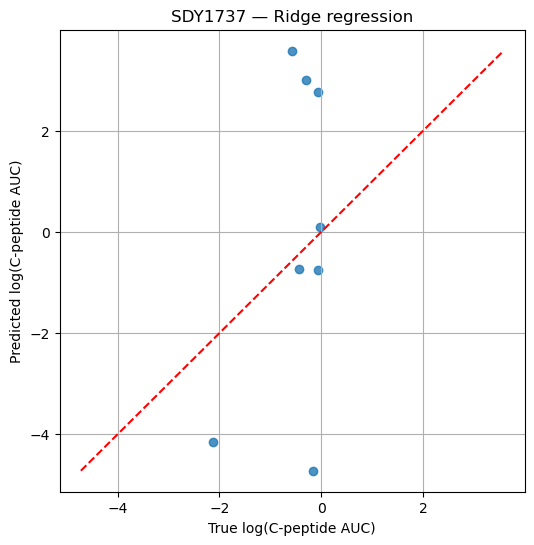

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

ridge_results = {}

for study, data in ridge_ready_dfs.items():
    print(f"\n===== Ridge regression for {study} =====")

    X = data["X"].values
    y = data["y"]

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42
    )

    # Fit ridge
    ridge = Ridge(alpha=0.001)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)

    # Metrics
    squared_errors = (y_test - y_pred) ** 2
    mean_mse   = np.mean(squared_errors)
    median_mse = np.median(squared_errors)
    iqr        = np.percentile(squared_errors, 75) - np.percentile(squared_errors, 25)

    print(f"Mean MSE:   {mean_mse:.4f}")
    print(f"Median MSE: {median_mse:.4f}")
    print(f"IQR:        {iqr:.4f}")

    # Regression equation
    coef_table = pd.Series(ridge.coef_, index=data["X"].columns)
    intercept = ridge.intercept_

    print("\nRegression coefficients:")
    print(coef_table.sort_values(ascending=False))
    print(f"Intercept: {intercept:.4f}")

    # Scatter plot (log scale)
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.8)
    lims = [
        min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
    ]
    plt.plot(lims, lims, "r--")
    plt.xlabel("True log(C‑peptide AUC)")
    plt.ylabel("Predicted log(C‑peptide AUC)")
    plt.title(f"{study} — Ridge regression")
    plt.grid(True)
    plt.show()

    ridge_results[study] = {
        "model": ridge,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "mean_mse": mean_mse,
        "median_mse": median_mse,
        "iqr": iqr,
        "coefficients": coef_table,
        "intercept": intercept
    }


In [7]:
# Step 1: Get the union of all feature names across studies
all_features = set()
for result in ridge_results.values():
    all_features.update(result["coefficients"].index.tolist())
all_features = sorted(all_features)  # consistent ordering

# Step 2: Reindex all local coefficient Series to this common set
coefs_aligned = []
intercepts = []

for result in ridge_results.values():
    coef_series = result["coefficients"].reindex(all_features, fill_value=0.0)
    coefs_aligned.append(coef_series.values)  # now same length
    intercepts.append(result["intercept"])

# Step 3: Stack safely
coefs_array = np.vstack(coefs_aligned)
intercepts_array = np.array(intercepts)

# Step 4: Median + IQR
federated_median_coef = np.median(coefs_array, axis=0)
coef_iqr = np.percentile(coefs_array, 75, axis=0) - np.percentile(coefs_array, 25, axis=0)

federated_median_intercept = np.median(intercepts_array)
intercept_iqr = np.percentile(intercepts_array, 75) - np.percentile(intercepts_array, 25)

# Step 5: Display
print("=== Federated Ridge Model (Median + IQR) ===")
print("Feature           Median     IQR")
print("-------------------------------")
for name, med, iqr_val in zip(all_features, federated_median_coef, coef_iqr):
    print(f"{name:<15s} {med: .6f}   {iqr_val: .6f}")
print(f"\nIntercept:        {federated_median_intercept:.6f}   IQR: {intercept_iqr:.6f}")


=== Federated Ridge Model (Median + IQR) ===
Feature           Median     IQR
-------------------------------
13-17            1.577163    0.899732
8-12            -0.314387    0.788582
>18              0.000000    0.742539
GAD65           -0.112305    0.911070
IA2IC            0.279646    0.175615
ICA              0.000000    0.014277
MIAA             0.483656    1.196410
Sex              0.000000    1.834115
ZNT8             0.000000    2.810606

Intercept:        -0.195291   IQR: 1.511434


In [8]:
# From previous step
federated_median_coef      # shape (n_features,)
federated_median_intercept
all_features               # list of feature names (aligned)


['13-17', '8-12', '>18', 'GAD65', 'IA2IC', 'ICA', 'MIAA', 'Sex', 'ZNT8']


=== Federated Model Evaluation on SDY569 ===
  Mean MSE:   0.7763
  Median MSE: 0.2845
  IQR:        1.4939


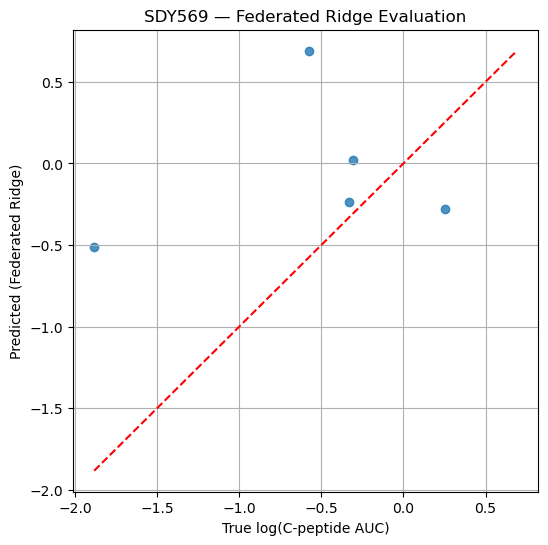


=== Federated Model Evaluation on SDY797 ===
  Mean MSE:   0.4446
  Median MSE: 0.2124
  IQR:        0.5718


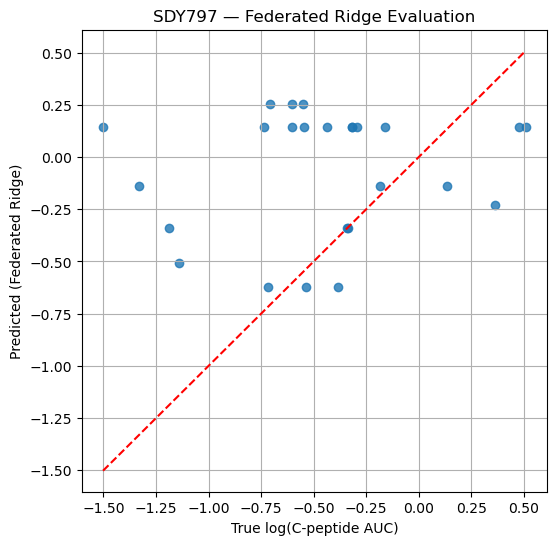


=== Federated Model Evaluation on SDY1737 ===
  Mean MSE:   3292.3037
  Median MSE: 2807.4237
  IQR:        4787.9946


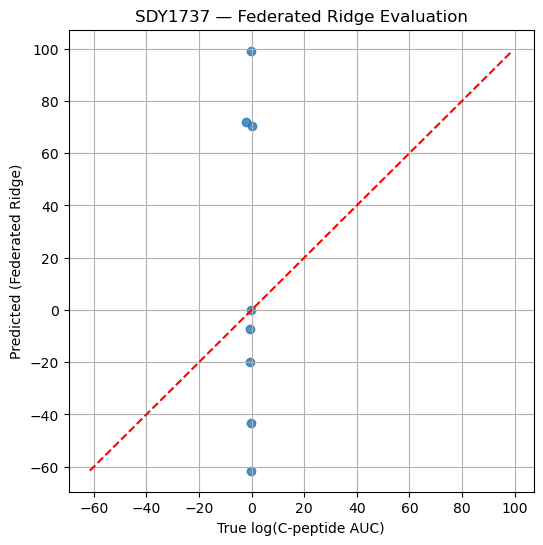

In [9]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

federated_eval_results = {}

for study, result in ridge_results.items():
    print(f"\n=== Federated Model Evaluation on {study} ===")

    # Extract aligned test features
    X_test_df = pd.DataFrame(result["X_test"], columns=result["coefficients"].index)
    X_test_aligned = X_test_df.reindex(columns=all_features, fill_value=0.0).values

    # Predict
    y_pred_fed = np.dot(X_test_aligned, federated_median_coef) + federated_median_intercept
    y_true     = result["y_test"]

    # Metrics
    squared_errors = (y_true - y_pred_fed) ** 2
    mean_mse   = np.mean(squared_errors)
    median_mse = np.median(squared_errors)
    iqr        = np.percentile(squared_errors, 75) - np.percentile(squared_errors, 25)

    print(f"  Mean MSE:   {mean_mse:.4f}")
    print(f"  Median MSE: {median_mse:.4f}")
    print(f"  IQR:        {iqr:.4f}")

    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred_fed, alpha=0.8)
    lims = [min(y_true.min(), y_pred_fed.min()), max(y_true.max(), y_pred_fed.max())]
    plt.plot(lims, lims, "r--")
    plt.xlabel("True log(C‑peptide AUC)")
    plt.ylabel("Predicted (Federated Ridge)")
    plt.title(f"{study} — Federated Ridge Evaluation")
    plt.grid(True)
    plt.show()

    # Save results
    federated_eval_results[study] = {
        "y_true": y_true,
        "y_pred": y_pred_fed,
        "mean_mse": mean_mse,
        "median_mse": median_mse,
        "iqr": iqr
    }
